# Hicks-Ray CSTR: the infinite-horizon terminal segment

Implements [Dinh et al. (2025)](https://doi.org/10.1016/j.jprocont.2025.103565),
"Nonlinear model predictive control with an infinite horizon approximation,"
*Journal of Process Control* 155, 103565.

Finite-horizon NMPC buys stability with terminal costs and terminal regions
that are hard to construct for nonlinear systems. The terminal segment takes
the alternative route: append the tail of the horizon to t = infinity,
compressed onto [0, 1) by the time transformation `tau = tanh(gamma*(t - tN))`,
and solve it inside the same NLP. The ingredients:

- **Dilated dynamics.** On the segment the dynamics carry the factor
  `gamma*(1 - tau^2)`, the transformation's Jacobian (eq. 25).
- **Gauss-Legendre collocation.** No collocation equation may sit at the
  singular endpoint `tau = 1`, so the segment discretizes with interior
  Legendre points, and endpoint values come from the polynomial extrapolation
  (eq. 26c).
- **Endpoint pin.** The segment endpoint `z(tau=1)`, the paper's evaluated
  endpoint (the Legendre extrapolation, eq. 26c), is pinned to the steady
  state by default (`terminal='soft'`: the eq. 36 endpoint relaxed by an L1
  penalty `mu`). `terminal='hard'` imposes the plain equality `z(tau=1) ==
  z_s` (eq. 21c); `terminal='none'` drops the pin, leaving the singular tail
  weights to drive the tail to settle on their own. A pin reads the declared
  steady-state targets. On this settled CSTR the tail reaches the setpoint
  either way; the pin is what stabilizes open-loop-unstable plants, where the
  cost alone does not pin the growing modes.
- **The true tail cost.** The stage cost integrates through the segment, so
  the terminal cost is the infinite-horizon cost-to-go itself, the paper's
  `(beta/dt)*phi_f`, overestimated by a safety factor `beta > 1` (Thm. 8).
- **The gamma rule.** `gamma` puts the segment's first collocation point one
  sampling time past the junction (Fig. 2), so time resolution is continuous
  across it.

Four takes on the same problem follow: model 1, the packaged path
(`drto.infinite_horizon`); model 2, the N = 50 finite-horizon baseline it is
measured against; model 3, the segment built by hand with the quadrature
state `phi`; and model 4, the same with the quadrature state eliminated into
explicit Gauss weights, the formulation the packaged transform uses.

## Model 1: the packaged path

The model is declared with drto (feature 002), `drto.infinite_horizon`
(feature 004) appends the terminal segment, and `drto.build_objective`
(feature 003) assembles the objective with the tail's Gauss-weighted terms.
Five sampling steps of horizon carry the infinite tail. The segment endpoint is pinned to the steady state by default (`terminal='soft'`, the paper's eq. 36).

The transform uses the explicit-weight formulation, model 4 below: the tail
cost enters the objective as Gauss-weighted stage-cost terms directly, with
no quadrature state.

In [1]:
%matplotlib inline
import pyomo.environ as pyo
from pyomo.dae import ContinuousSet, DerivativeVar
import drto
from pyomo.environ import (
    ConcreteModel, Set, RangeSet, Var, Param, Constraint, minimize, sqrt, Objective, TransformationFactory,
    SolverFactory, value, exp)
import matplotlib.pyplot as plt
from pyomo.dae import ContinuousSet, DerivativeVar
from pyomo_cvp import declare_profile, control_value
import pyomo_pounce  
import numpy as np
import math

N = 5
h=1
m1 = ConcreteModel()
m1.t = ContinuousSet(initialize=pyo.RangeSet(0,N*h,h))  # the sample grid: 5 steps, dt = 1
m1.u1sf = Param(initialize=600, mutable=True)    # coolant-flow scale factor
m1.u2sf = Param(initialize=40, mutable=True)     # residence-time scale factor
m1.k0 = Param(initialize=300, mutable=True)      # Arrhenius pre-exponential
m1.ea = Param(initialize=5, mutable=True)        # dimensionless activation energy
m1.a0 = Param(initialize=1.95e-4, mutable=True)  # heat-transfer coefficient
m1.ztcw = Param(initialize=0.38, mutable=True)   # coolant temperature
m1.ztf = Param(initialize=0.395, mutable=True)   # feed temperature

m1.zc_ss = Param(initialize=0.6416, mutable=True)   # steady-state targets
m1.zt_ss = Param(initialize=0.5387, mutable=True)
m1.v1_ss = Param(initialize=0.57828, mutable=True)
m1.v2_ss = Param(initialize=0.49989, mutable=True)
m1.zc_hat =Param(initialize=0.625, mutable=True)   # state feedback hooks
m1.zt_hat = Param(initialize=0.525, mutable=True)

m1.zc = Var(m1.t, bounds=(0, 1), initialize=0.6416)
m1.zt = Var(m1.t, bounds=(0, None), initialize=0.5387)
m1.dzc = DerivativeVar(m1.zc, wrt=m1.t)
m1.dzt = DerivativeVar(m1.zt, wrt=m1.t)
m1.v1 = Var(m1.t, bounds=(0.166666666666667, 1), initialize=0.57828)
m1.v2 = Var(m1.t, bounds=(0.025, 1), initialize=0.49989)
m1.cost = pyo.Var(m1.t)

@m1.Constraint(m1.t)
def zc_ode(m, t):
    return m.dzc[t] == (1 - m.zc[t])/(m.u2sf*m.v2[t]) - m.k0*m.zc[t]*pyo.exp(-m.ea/m.zt[t])

@m1.Constraint(m1.t)
def zt_ode(m, t):
    return m.dzt[t] == ((m.ztf - m.zt[t])/(m.u2sf*m.v2[t])
                        + m.k0*m.zc[t]*pyo.exp(-m.ea/m.zt[t])
                        - m.a0*m.u1sf*m.v1[t]*(m.zt[t] - m.ztcw))

@m1.Constraint(sorted(m1.t)[:-1])  # the terminal cost owns the final time
def stage(m, t):
    return m.cost[t] == (10*(m.zc[t] - m.zc_ss)**2 + 2*(m.zt[t] - m.zt_ss)**2
                         + (m.v1[t] - m.v1_ss)**2 + 0.5*(m.v2[t] - m.v2_ss)**2)

@m1.Constraint()
def zc_init(m):
    return m.zc[0] == m.zc_hat

@m1.Constraint()
def zt_init(m):
    return m.zt[0] == m.zt_hat

drto.horizon(m1.t)
drto.state(m1.zc, m1.zt)
drto.dynamics(m1.zc_ode, m1.zt_ode)
drto.control(m1.v1, m1.v2, profile="piecewise_constant")
drto.tracking_stage_cost(m1.stage)
drto.initial_condition(m1.zc_init, m1.zt_init)
drto.steady_state(m1.zc, m1.zc_ss)
drto.steady_state(m1.zt, m1.zt_ss)
drto.steady_state_control(m1.v1, m1.v1_ss)
drto.steady_state_control(m1.v2, m1.v2_ss)

TransformationFactory("dae.collocation").apply_to(
    m1, wrt=m1.t, nfe=N, ncp=3, scheme="LAGRANGE-RADAU")
TransformationFactory("drto.infinite_horizon").apply_to(
    m1,
    nfe=3,                    # finite elements on the terminal segment
    ncp=5,                    # Gauss-Legendre points per element
    beta=1.2,                 # tail overestimation factor, > 1
    gamma="rule",             # the mesh rule, tanh(gamma*dt) = tau_11;
                              # pass a number to override
    profile="collocation",    # segment control profile (pyomo-cvp)
)
TransformationFactory("drto.parameterize").apply_to(m1)  # the finite-horizon profiles
drto.build_objective(m1)
SolverFactory("pounce").solve(m1, tee=True)

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 147, 'Number of variables': 181, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'POUNCE 0.8.0\\x3a SolveSucceeded', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 0.010138750076293945}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

In [2]:
seg = m1.drto_infinite_horizon
print(f"first move   : v1 = {pyo.value(m1.v1[0]):.5f}, v2 = {pyo.value(m1.v2[0]):.5f}")
print(f"tail endpoint: zc = {pyo.value(seg.zc[1]):.5f}, zt = {pyo.value(seg.zt[1]):.5f}"
      f"   (setpoints {pyo.value(m1.zc_ss):.5f}, {pyo.value(m1.zt_ss):.5f})")
drto.info(m1)

horizon,"t (ContinuousSet, 16 points)"
states,"zc (free), zt (free)"
dynamics,dzc[t] == (1 - zc[t])/(u2sf*v2[t]) - k0*zc[t]*exp(- ea/zt[t]) for t in t
dynamics,dzt[t] == (ztf - zt[t])/(u2sf*v2[t]) + k0*zc[t]*exp(- ea/zt[t]) - a0*u1sf*v1[t]*(zt[t] - ztcw) for t in t
controls,"v1 (piecewise_constant, free), v2 (piecewise_constant, free)"
tracking stage cost,cost[t] == 10*(zc[t] - zc_ss)**2 + 2*(zt[t] - zt_ss)**2 + (v1[t] - v1_ss)**2 + 0.5*(v2[t] - v2_ss)**2 for t in sorted(t)[:-1]
initial conditions,zc[0] == zc_hat
initial conditions,zt[0] == zt_hat
steady-state targets,"zc_ss (of zc), zt_ss (of zt)"
steady-state control targets,"v1_ss (of v1), v2_ss (of v2)"
cost_group,"drto_infinite_horizon, drto_infinite_horizon"


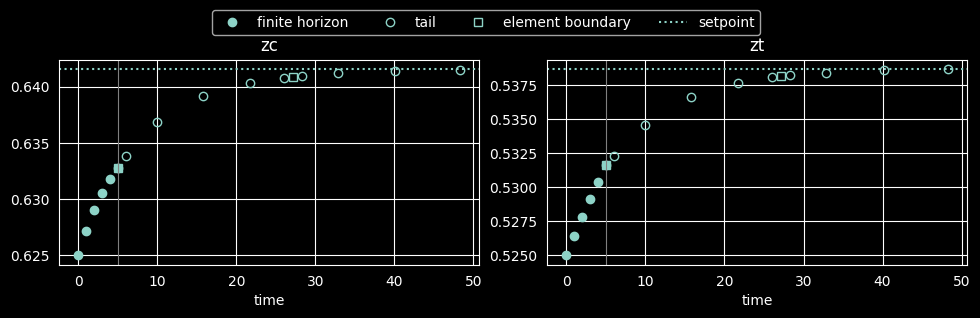

In [3]:
# drto-aware plotting: states, targets, and the tail read from the registry
from plotting import plot_states, plot_controls, plot_stage_cost
from matplotlib.lines import Line2D  # the model 3 and 4 plot cells use it

plot_states(m1);
plt.show()

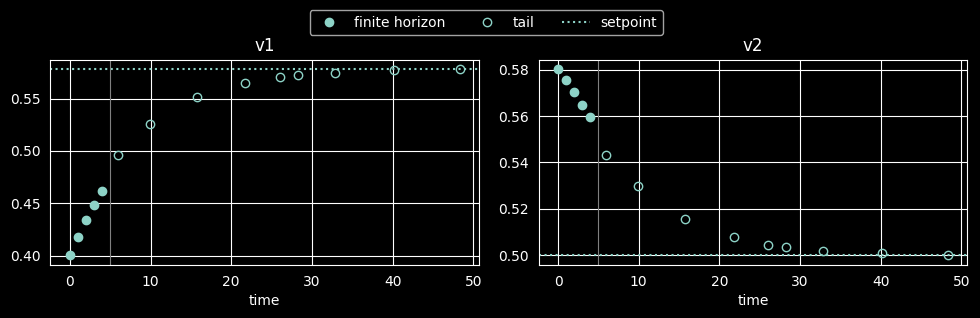

In [4]:
plot_controls(m1);
plt.show()

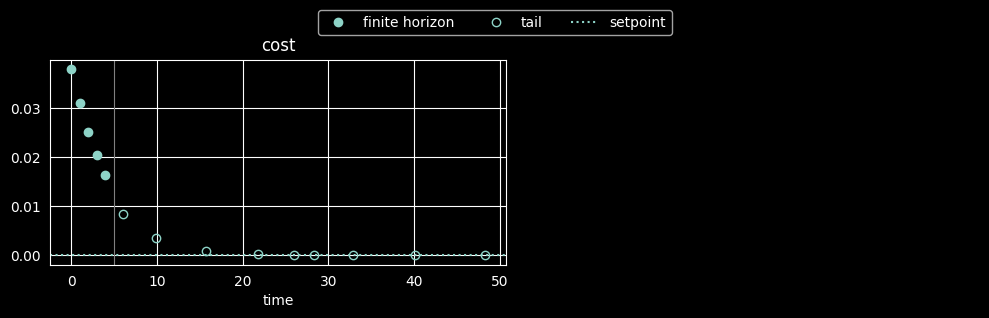

In [5]:
plot_stage_cost(m1);
plt.show()

## Model 2: the finite-horizon baseline (N = 50)

The original pyomo-cvp Hicks example: fifty sampling steps, piecewise-constant
controls, solved with pounce. This is the long-horizon policy the
infinite-horizon runs are measured against, and the closing cell reads control
sensitivities off the converged solve.

In [6]:
m2 = ConcreteModel()
N2 = 50  # number of finite elements over the horizon
m2.i = ContinuousSet(initialize=RangeSet(0,N2*h,h))  # time: the horizon, 0..N

# Hicks-Ray CSTR: a first-order exothermic reaction A -> B in a cooled
# continuous stirred-tank reactor. Two states (concentration and
# temperature), two manipulated inputs (coolant flow and residence time),
# all dimensionless.

# steady-state targets the controller drives toward
m2.xss = Param(RangeSet(1,2), initialize = {1: 0.6416, 2: 0.5387})    # target state: 1 = reactant concentration, 2 = reactor temperature
m2.uss = Param(RangeSet(1,2), initialize = {1: 0.57828, 2: 0.49989})  # target input: 1 = coolant flow v1, 2 = residence time v2

# states (absolute values, not deviations)
m2.zc = Var(m2.i, bounds = (0,1), initialize = m2.xss[1])     # reactant concentration, normalized so the feed is 1 (0 = fully converted)
m2.zt = Var(m2.i, bounds = (0,None),initialize = m2.xss[2])   # reactor temperature (dimensionless)

# time derivatives of the states: dc/dt and dT/dt
m2.zcdot = DerivativeVar(m2.zc, wrt=m2.i)
m2.ztdot = DerivativeVar(m2.zt, wrt=m2.i)

# manipulated inputs
m2.v1 = Var(m2.i,bounds = (.166666666666667,1), initialize = m2.uss[1])  # coolant flow: the cooling that carries reaction heat away
m2.v2 = Var(m2.i, bounds = (.025,1), initialize = m2.uss[2])             # sets the residence time; u2sf*v2 = V/F, so 1/(u2sf*v2) is the dilution rate
declare_profile(m2.v1, m2.v2, wrt=m2.i, profile="piecewise_constant")

# cost variables
m2.track = Var()  # accumulated tracking cost over t = 0..N-1 (the objective value)
m2.term = Var()   # terminal cost: squared state deviation at the final time

# parameters
m2.u1sf = Param(initialize = 600)      # scale factor turning v1 into a physical coolant flow
m2.u2sf = Param(initialize = 40)       # scale factor turning v2 into the residence time V/F
m2.k0 = Param(initialize = 300)        # Arrhenius pre-exponential factor (the reaction rate constant)
m2.ea = Param(initialize = 5)          # dimensionless activation energy in exp(-ea/zt)
m2.a0 = Param(initialize = .000195)    # cooling heat-transfer coefficient; a0*u1sf*v1 is the heat-removal rate
m2.ztcw = Param(initialize = .38)      # coolant temperature (the sink the reactor rejects heat to)
m2.ztf = Param(initialize = .395)      # feed temperature

# initial state at t=0, mutable so it can be updated as feedback; also the sensitivity parameters
m2.zcinit = Param(initialize = .625, mutable=True)  # initial reactant concentration
m2.ztinit = Param(initialize = .525, mutable=True)  # initial reactor temperature

# material balance: dc/dt = feed dilution - reaction consumption
@m2.Constraint(m2.i)
def zcdot_def(m2,i):
    # (1-zc)/(u2sf*v2): fresh feed (concentration 1) exchanging the contents at dilution rate 1/(u2sf*v2)
    # k0*zc*exp(-ea/zt): first-order Arrhenius reaction consuming reactant
    return m2.zcdot[i] == (1-m2.zc[i])/(m2.u2sf*m2.v2[i]) - m2.k0*m2.zc[i]*exp(-m2.ea/m2.zt[i]) 

# energy balance: dT/dt = feed enthalpy + reaction heat - cooling
@m2.Constraint(m2.i)
def ztdot_def(m2,i):
    # (ztf-zt)/(u2sf*v2): sensible heat carried in by feed at temperature ztf
    # k0*zc*exp(-ea/zt): heat released by the exothermic reaction (heat of reaction normalized to 1)
    # a0*u1sf*v1*(zt-ztcw): heat removed by coolant, driven by the reactor-minus-coolant temperature gap
    return m2.ztdot[i] == (m2.ztf - m2.zt[i])/(m2.u2sf*m2.v2[i])+m2.k0*m2.zc[i]*exp(-m2.ea/m2.zt[i]) - m2.a0*m2.u1sf*m2.v1[i]*(m2.zt[i]-m2.ztcw) 

# objective terms
@m2.Constraint()
def tracking_def(m2):
    # weighted sum of squared deviations of states (zc, zt) and inputs (v1, v2) from steady state, over t = 0..N-1
    return m2.track == sum( 10*(m2.zc[i]- m2.xss[1])**2 + 2*(m2.zt[i]-m2.xss[2])**2+(m2.v1[i]- m2.uss[1])**2 + 0.5*(m2.v2[i]-m2.uss[2])**2 for i in sorted(m2.i)[:-1])
    
tN = m2.i.last() 
@m2.Constraint()
def term_def(m2):
    # terminal penalty on the state deviation at the final time tN
    return m2.term == 10*(m2.zc[tN]- m2.xss[1])**2 + 2*(m2.zt[tN]-m2.xss[2])**2

# initial conditions: pin each state at t=0 to its initial value
@m2.Constraint()
def zcinit_def(m2):
    return m2.zc[0] == m2.zcinit

@m2.Constraint()
def ztinit_def(m2):
    return m2.zt[0] == m2.ztinit

m2.obj = Objective(expr = m2.track+m2.term, sense = minimize)

In [7]:
# Transform and solve. With sensitivity parameters declared, the ordinary
# pounce solve keeps the converged KKT factorization for the queries below.
TransformationFactory("dae.collocation").apply_to(
    m2, nfe=N, ncp=3, scheme="LAGRANGE-RADAU")
TransformationFactory("cvp.parameterize").apply_to(m2)
SolverFactory("pounce").solve(m2,tee=True)

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 606, 'Number of variables': 706, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'POUNCE 0.8.0\\x3a SolveSucceeded', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 0.021430015563964844}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

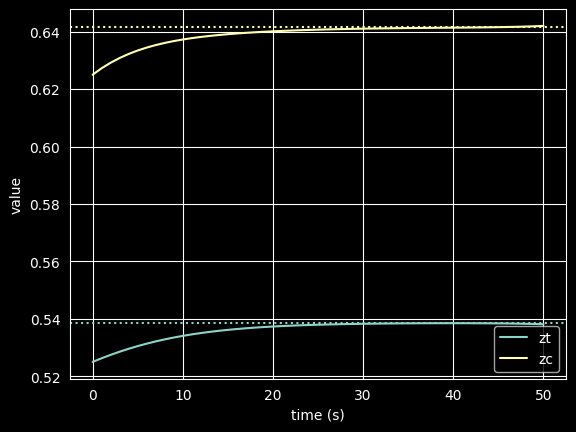

In [8]:
#Plot states

t = m2.i.get_finite_elements()      

zc = [value(m2.zc[i]) for i in t]
zt = [value(m2.zt[i]) for i in t]

# Plot optimal state trajectories
line_zt, = plt.plot(t, zt, label='zt')
line_zc, = plt.plot(t, zc, label='zc')

# Steady-state horizontal lines, matched to each trajectory's color
plt.axhline(m2.xss[1], color=line_zc.get_color(), linestyle=':')
plt.axhline(m2.xss[2], color=line_zt.get_color(), linestyle=':')


plt.xlabel('time (s)')
plt.ylabel('value')
plt.legend()
plt.show()

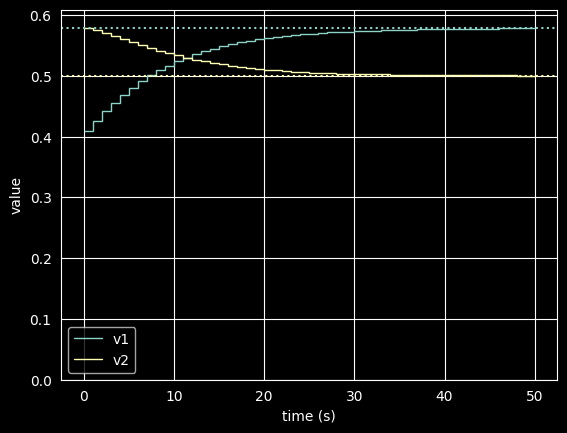

In [9]:
# Plot controls

t = m2.i.get_finite_elements()

v1 = [value(m2.v1[i]) for i in t[:-1]]
v2 = [value(m2.v2[i]) for i in t[:-1]]

# Plot the optimal control trajectories: coolant flow v1 and residence time v2
plt.figure()
line_v1=plt.stairs(v1, t, baseline=None, label='v1')
line_v2=plt.stairs(v2, t, baseline=None, label='v2')

# Steady-state horizontal lines, matched to each trajectory's color
plt.axhline(m2.uss[1], color=line_zt.get_color(), linestyle=':')
plt.axhline(m2.uss[2], color=line_zc.get_color(), linestyle=':')

plt.xlabel('time (s)')
plt.ylabel('value')
plt.legend()
plt.show()


## Model 3: the segment by hand, with the quadrature state

The construction the transform performs, written out in pyomo.dae on a short
horizon (N = 5): the segment ContinuousSet with the dilated dynamics at
interior Gauss-Legendre points, the linking constraints, and
the tail cost integrated by the quadrature state `phi` (eq. 28), entering the
objective as `beta*phi(1)`. The segment controls carry a pyomo-cvp
`'collocation'` profile, so every copy, boundaries included, is defined by
the element polynomials.

In [10]:
m3 = ConcreteModel()
N3 = 5  # short finite horizon: 5 elements instead of 50
m3.i = ContinuousSet(initialize=RangeSet(0, N3*h, h))

# --- finite-horizon part: the same Hicks-Ray CSTR as model 2 ---

m3.xss = Param(RangeSet(1,2), initialize = {1: 0.6416, 2: 0.5387})
m3.uss = Param(RangeSet(1,2), initialize = {1: 0.57828, 2: 0.49989})

m3.zc = Var(m3.i, bounds = (0,1), initialize = m3.xss[1])
m3.zt = Var(m3.i, bounds = (0,None), initialize = m3.xss[2])
m3.zcdot = DerivativeVar(m3.zc, wrt=m3.i)
m3.ztdot = DerivativeVar(m3.zt, wrt=m3.i)

m3.v1 = Var(m3.i, bounds = (.166666666666667,1), initialize = m3.uss[1])
m3.v2 = Var(m3.i, bounds = (.025,1), initialize = m3.uss[2])
declare_profile(m3.v1, m3.v2, wrt=m3.i, profile="piecewise_constant")

m3.track = Var()

m3.u1sf = Param(initialize = 600)
m3.u2sf = Param(initialize = 40)
m3.k0 = Param(initialize = 300)
m3.ea = Param(initialize = 5)
m3.a0 = Param(initialize = .000195)
m3.ztcw = Param(initialize = .38)
m3.ztf = Param(initialize = .395)

m3.zcinit = Param(initialize = .625, mutable=True)
m3.ztinit = Param(initialize = .525, mutable=True)

# the model equations and the stage cost, shared by the finite horizon and
# the terminal segment below
def f_c(m, zc, zt, v1, v2):
    return (1-zc)/(m.u2sf*v2) - m.k0*zc*exp(-m.ea/zt)

def f_t(m, zc, zt, v1, v2):
    return (m.ztf - zt)/(m.u2sf*v2) + m.k0*zc*exp(-m.ea/zt) - m.a0*m.u1sf*v1*(zt-m.ztcw)

def psi(m, zc, zt, v1, v2):
    return 10*(zc - m.xss[1])**2 + 2*(zt - m.xss[2])**2 \
         + (v1 - m.uss[1])**2 + 0.5*(v2 - m.uss[2])**2

@m3.Constraint(m3.i)
def zcdot_def(m,i):
    return m.zcdot[i] == f_c(m, m.zc[i], m.zt[i], m.v1[i], m.v2[i])

@m3.Constraint(m3.i)
def ztdot_def(m,i):
    return m.ztdot[i] == f_t(m, m.zc[i], m.zt[i], m.v1[i], m.v2[i])

@m3.Constraint()
def tracking_def(m):
    return m.track == sum(psi(m, m.zc[i], m.zt[i], m.v1[i], m.v2[i])
                          for i in sorted(m.i)[:-1])

@m3.Constraint()
def zcinit_def(m):
    return m.zc[0] == m.zcinit

@m3.Constraint()
def ztinit_def(m):
    return m3.zt[0] == m.ztinit

# --- infinite-horizon terminal segment (Dinh et al. 2025) ---

tN = m3.i.last()
m3.tau = ContinuousSet(bounds=(0, 1))   # transformed time tanh(gamma*(t - tN))
m3.gamma = Param(initialize=0.02, mutable=True)  # set from the mesh after discretizing
m3.beta = Param(initialize=1.2)                  # tail-cost safety factor, >= 1

# segment states and controls: same bounds as the finite part. The controls
# are profiles (pyomo-cvp): free values at each element's collocation points,
# every other copy, boundaries included, defined by the element's Lagrange
# polynomial. k = ncp keeps all collocation values free, so this is the
# paper's representation of v(tau) with no extra restriction.
m3.zc_s = Var(m3.tau, bounds=(0,1), initialize=m3.xss[1])
m3.zt_s = Var(m3.tau, bounds=(0,None), initialize=m3.xss[2])
m3.v1_s = Var(m3.tau, bounds=(.166666666666667,1), initialize=m3.uss[1])
m3.v2_s = Var(m3.tau, bounds=(.025,1), initialize=m3.uss[2])
declare_profile(m3.v1_s, m3.v2_s, wrt=m3.tau, profile='collocation')
m3.zc_sdot = DerivativeVar(m3.zc_s, wrt=m3.tau)
m3.zt_sdot = DerivativeVar(m3.zt_s, wrt=m3.tau)

# quadrature state: phi(1) is the tail cost integral from tN to infinity
m3.phi = Var(m3.tau, initialize=0)
m3.phidot = DerivativeVar(m3.phi, wrt=m3.tau)
m3.phi[0].fix(0)

# dilated dynamics (eq. 25) at interior collocation points only: with
# Gauss-Legendre points there is no collocation equation at tau = 0 or 1,
# matching the paper's discretization (eq. 26)
@m3.Constraint(m3.tau)
def seg_dyn_c(m, s):
    if s in m.tau.get_finite_elements():
        return Constraint.Skip
    return m.gamma*(1 - s**2)*m.zc_sdot[s] == f_c(m, m.zc_s[s], m.zt_s[s], m.v1_s[s], m.v2_s[s])

@m3.Constraint(m3.tau)
def seg_dyn_t(m, s):
    if s in m.tau.get_finite_elements():
        return Constraint.Skip
    return m.gamma*(1 - s**2)*m.zt_sdot[s] == f_t(m, m.zc_s[s], m.zt_s[s], m.v1_s[s], m.v2_s[s])

# tail-cost quadrature (eq. 28)
@m3.Constraint(m3.tau)
def seg_quad(m, s):
    if s in m.tau.get_finite_elements():
        return Constraint.Skip
    return m.gamma*(1 - s**2)*m.phidot[s] == psi(m, m.zc_s[s], m.zt_s[s], m.v1_s[s], m.v2_s[s])

# stitch the segment onto the end of the finite horizon
@m3.Constraint()
def link_c(m):
    return m.zc_s[0] == m.zc[tN]

@m3.Constraint()
def link_t(m):
    return m.zt_s[0] == m.zt[tN]

# objective: finite tracking cost + beta * infinite tail cost
m3.obj = Objective(expr=m3.track + m3.beta*m3.phi[1], sense=minimize)

In [11]:
# Radau on the finite horizon (as in model 1), Gauss-Legendre on the segment
TransformationFactory("dae.collocation").apply_to(
    m3, wrt=m3.i, nfe=N3, ncp=3, scheme="LAGRANGE-RADAU")
TransformationFactory("dae.collocation").apply_to(
    m3, wrt=m3.tau, nfe=3, ncp=5, scheme="LAGRANGE-LEGENDRE")
TransformationFactory("cvp.parameterize").apply_to(m3)

# gamma rule (paper Fig. 2): put the segment's first collocation point one
# sampling time past tN, so resolution is continuous across the junction
tau11 = sorted(m3.tau)[1]
m3.gamma.set_value(math.atanh(tau11) / h)
print(f"tau_11 = {tau11:.6f}  ->  gamma = {value(m3.gamma):.6f}")

SolverFactory("pounce").solve(m3, tee=True)

print(f"finite tracking cost = {value(m3.track):.6f}")
print(f"tail cost phi(1)     = {value(m3.phi[1]):.6f}")
print(f"track + tail         = {value(m3.track) + value(m3.phi[1]):.6f}"
      f"   (model 2, N=50: {value(m2.track):.6f})")
print(f"endpoint (zc, zt, v1, v2) = ({value(m3.zc_s[1]):.5f}, {value(m3.zt_s[1]):.5f}, "
      f"{control_value(m3.v1_s, 1):.5f}, {control_value(m3.v2_s, 1):.5f})")

finite tracking cost = 0.131000
tail cost phi(1)     = 0.046236
track + tail         = 0.177236   (model 2, N=50: 0.176721)
endpoint (zc, zt, v1, v2) = (0.64160, 0.53870, 0.57828, 0.49989)


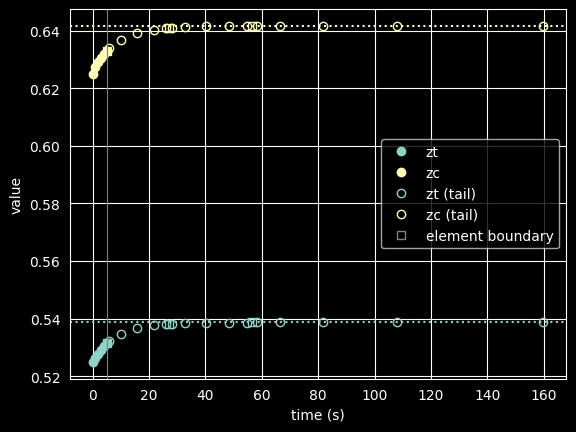

In [12]:
# Plot states: points only. Finite horizon filled, infinite tail open.
# The tail is mapped back to real time through t = tN + atanh(tau)/gamma
# and clipped to the same window as the model 1 plot. Squares mark the
# segment's element boundaries (continuity extrapolations).

t3 = m3.i.get_finite_elements()
zc3 = [value(m3.zc[i]) for i in t3]
zt3 = [value(m3.zt[i]) for i in t3]

g = value(m3.gamma)
fe3 = set(m3.tau.get_finite_elements())
tail = [(tN + math.atanh(s)/g, value(m3.zc_s[s]), value(m3.zt_s[s]), s in fe3)
        for s in sorted(m3.tau) if s < 1]
t_tail = [p[0] for p in tail if not p[3]]
zc_tail = [p[1] for p in tail if not p[3]]
zt_tail = [p[2] for p in tail if not p[3]]
t_fe3 = [p[0] for p in tail if p[3]]
zc_fe3 = [p[1] for p in tail if p[3]]
zt_fe3 = [p[2] for p in tail if p[3]]

line_zt, = plt.plot(t3, zt3, 'o', label='zt')
line_zc, = plt.plot(t3, zc3, 'o', label='zc')
plt.plot(t_tail, zt_tail, 'o', mfc='none', color=line_zt.get_color(), label='zt (tail)')
plt.plot(t_tail, zc_tail, 'o', mfc='none', color=line_zc.get_color(), label='zc (tail)')
plt.plot(t_fe3, zt_fe3, 's', mfc='none', color=line_zt.get_color())
plt.plot(t_fe3, zc_fe3, 's', mfc='none', color=line_zc.get_color())

plt.axhline(m3.xss[1], color=line_zc.get_color(), linestyle=':')
plt.axhline(m3.xss[2], color=line_zt.get_color(), linestyle=':')
plt.axvline(tN, color='grey', linewidth=0.8)

plt.xlabel('time (s)')
plt.ylabel('value')
handles, labels = plt.gca().get_legend_handles_labels()
handles.append(Line2D([], [], marker='s', mfc='none', color='grey', linestyle=''))
labels.append('element boundary')
plt.legend(handles, labels)
plt.show()

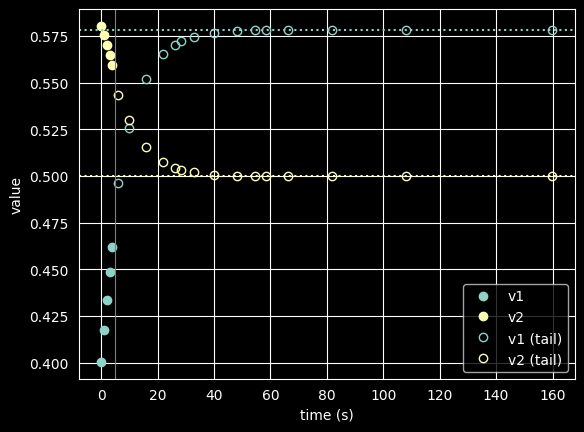

In [13]:
# Plot controls: points only. Piecewise-constant moves on the finite
# horizon (one point per move, at the start of its interval), then the free
# collocation-point values through the tail (open markers).

t3 = m3.i.get_finite_elements()
v1_3 = [value(m3.v1[i]) for i in t3[:-1]]
v3_3 = [value(m3.v2[i]) for i in t3[:-1]]

# The segment controls are cvp profiles: the free values sit at the element
# collocation points (the profile is defined everywhere in between, see
# control_value). Plot the free values.
v_tail = [(tN + math.atanh(s)/g, value(m3.v1_s[s]), value(m3.v2_s[s]))
          for s in sorted(m3.v1_s.index_set()) if s < 1]
t_vt = [p[0] for p in v_tail]
v1_t = [p[1] for p in v_tail]
v2_t = [p[2] for p in v_tail]

plt.figure()
line_v1, = plt.plot(t3[:-1], v1_3, 'o', label='v1')
line_v2, = plt.plot(t3[:-1], v3_3, 'o', label='v2')
plt.plot(t_vt, v1_t, 'o', mfc='none', color=line_v1.get_color(), label='v1 (tail)')
plt.plot(t_vt, v2_t, 'o', mfc='none', color=line_v2.get_color(), label='v2 (tail)')

plt.axhline(m3.uss[1], color=line_v1.get_color(), linestyle=':')
plt.axhline(m3.uss[2], color=line_v2.get_color(), linestyle=':')
plt.axvline(tN, color='grey', linewidth=0.8)

plt.xlabel('time (s)')
plt.ylabel('value')
plt.legend()
plt.show()

## Model 4: the weight version, no phi

`phi` is linear bookkeeping: integrating `dphi/dt = psi` by K-point Gauss
collocation is identically K-point Gauss quadrature, so `phi(1)` collapses to
a fixed weighted sum of the stage cost at the segment's collocation points.
Model 4 is model 3 with `phi` deleted and the tail cost written directly into
the objective:

    Phi = beta * sum_{i,k}  h_i * omega_k * psi(z_ik, v_ik) / (gamma*(1 - tau_ik^2))

where `omega_k` are the Gauss-Legendre weights and the `1/(gamma*(1 - tau^2))`
factor is the time-transformation Jacobian, the real-time span each
collocation point represents. The control problem is unchanged: the objective
is still a weighted sum of the one declared stage cost, its index set just
grows by the segment points, with weights supplied by the discretization.
This is the shape `drto.infinite_horizon` (feature 004) implements: grow the mesh, grow
the dynamics, grow the objective sum, after discretization. The solution is
identical to model 3 to solver tolerance.

In [14]:
m4 = ConcreteModel()
m4.i = ContinuousSet(initialize=RangeSet(0, N3*h, h))

# --- finite-horizon part: same as model 3 ---

m4.xss = Param(RangeSet(1,2), initialize = {1: 0.6416, 2: 0.5387})
m4.uss = Param(RangeSet(1,2), initialize = {1: 0.57828, 2: 0.49989})

m4.zc = Var(m4.i, bounds = (0,1), initialize = m4.xss[1])
m4.zt = Var(m4.i, bounds = (0,None), initialize = m4.xss[2])
m4.zcdot = DerivativeVar(m4.zc, wrt=m4.i)
m4.ztdot = DerivativeVar(m4.zt, wrt=m4.i)

m4.v1 = Var(m4.i, bounds = (.166666666666667,1), initialize = m4.uss[1])
m4.v2 = Var(m4.i, bounds = (.025,1), initialize = m4.uss[2])
declare_profile(m4.v1, m4.v2, wrt=m4.i, profile="piecewise_constant")

m4.track = Var()

m4.u1sf = Param(initialize = 600)
m4.u2sf = Param(initialize = 40)
m4.k0 = Param(initialize = 300)
m4.ea = Param(initialize = 5)
m4.a0 = Param(initialize = .000195)
m4.ztcw = Param(initialize = .38)
m4.ztf = Param(initialize = .395)

m4.zcinit = Param(initialize = .625, mutable=True)
m4.ztinit = Param(initialize = .525, mutable=True)

# f_c, f_t, psi are the shared model equations from the model 3 cell
@m4.Constraint(m4.i)
def zcdot_def(m,i):
    return m.zcdot[i] == f_c(m, m.zc[i], m.zt[i], m.v1[i], m.v2[i])

@m4.Constraint(m4.i)
def ztdot_def(m,i):
    return m.ztdot[i] == f_t(m, m.zc[i], m.zt[i], m.v1[i], m.v2[i])

@m4.Constraint()
def tracking_def(m):
    return m.track == sum(psi(m, m.zc[i], m.zt[i], m.v1[i], m.v2[i])
                          for i in sorted(m.i)[:-1])

@m4.Constraint()
def zcinit_def(m):
    return m.zc[0] == m.zcinit

@m4.Constraint()
def ztinit_def(m):
    return m.zt[0] == m.ztinit

# --- terminal segment: as in model 3, minus phi ---

tN4 = m4.i.last()
m4.tau = ContinuousSet(bounds=(0, 1))
m4.gamma = Param(initialize=0.02, mutable=True)
m4.beta = Param(initialize=1.2)

m4.zc_s = Var(m4.tau, bounds=(0,1), initialize=m4.xss[1])
m4.zt_s = Var(m4.tau, bounds=(0,None), initialize=m4.xss[2])
m4.v1_s = Var(m4.tau, bounds=(.166666666666667,1), initialize=m4.uss[1])
m4.v2_s = Var(m4.tau, bounds=(.025,1), initialize=m4.uss[2])
declare_profile(m4.v1_s, m4.v2_s, wrt=m4.tau, profile='collocation')
m4.zc_sdot = DerivativeVar(m4.zc_s, wrt=m4.tau)
m4.zt_sdot = DerivativeVar(m4.zt_s, wrt=m4.tau)

@m4.Constraint(m4.tau)
def seg_dyn_c(m, s):
    if s in m.tau.get_finite_elements():
        return Constraint.Skip
    return m.gamma*(1 - s**2)*m.zc_sdot[s] == f_c(m, m.zc_s[s], m.zt_s[s], m.v1_s[s], m.v2_s[s])

@m4.Constraint(m4.tau)
def seg_dyn_t(m, s):
    if s in m.tau.get_finite_elements():
        return Constraint.Skip
    return m.gamma*(1 - s**2)*m.zt_sdot[s] == f_t(m, m.zc_s[s], m.zt_s[s], m.v1_s[s], m.v2_s[s])

@m4.Constraint()
def link_c(m):
    return m.zc_s[0] == m.zc[tN4]

@m4.Constraint()
def link_t(m):
    return m.zt_s[0] == m.zt[tN4]

# no quadrature state: the tail cost enters the objective directly, with
# explicit weights, after discretization (next cell)

In [15]:
TransformationFactory("dae.collocation").apply_to(
    m4, wrt=m4.i, nfe=N3, ncp=3, scheme="LAGRANGE-RADAU")
TransformationFactory("dae.collocation").apply_to(
    m4, wrt=m4.tau, nfe=3, ncp=5, scheme="LAGRANGE-LEGENDRE")
TransformationFactory("cvp.parameterize").apply_to(m4)

m4.gamma.set_value(math.atanh(sorted(m4.tau)[1]) / h)

# tail cost as explicit Gauss weights: phi(1), eliminated. omega_k are the
# 5-point Gauss-Legendre weights on [0,1]; the interior points of each
# segment element are exactly the corresponding nodes.
_, omega = np.polynomial.legendre.leggauss(5)
omega = omega / 2
fe3 = m4.tau.get_finite_elements()
pts3 = sorted(m4.tau)
tail3 = 0
for iel in range(len(fe3) - 1):
    h_i = fe3[iel+1] - fe3[iel]
    interior = [p for p in pts3 if fe3[iel] < p < fe3[iel+1]]
    for p, w in zip(interior, omega):
        tail3 = tail3 + h_i * w * psi(m4, m4.zc_s[p], m4.zt_s[p],
                                      m4.v1_s[p], m4.v2_s[p]) / (m4.gamma*(1 - p**2))

m4.obj = Objective(expr=m4.track + m4.beta*tail3, sense=minimize)

SolverFactory("pounce").solve(m4, tee=True)

print(f"model 4 (weights): track = {value(m4.track):.9f}   tail = {value(tail3):.9f}")
print(f"model 3 (phi)    : track = {value(m3.track):.9f}   tail = {value(m3.phi[1]):.9f}")
print(f"first controls   : m4 ({value(m4.v1[0]):.6f}, {value(m4.v2[0]):.6f})"
      f"   m3 ({value(m3.v1[0]):.6f}, {value(m3.v2[0]):.6f})")

model 4 (weights): track = 0.131000182   tail = 0.046235769
model 3 (phi)    : track = 0.131000182   tail = 0.046235769
first controls   : m4 (0.400378, 0.580429)   m3 (0.400378, 0.580429)


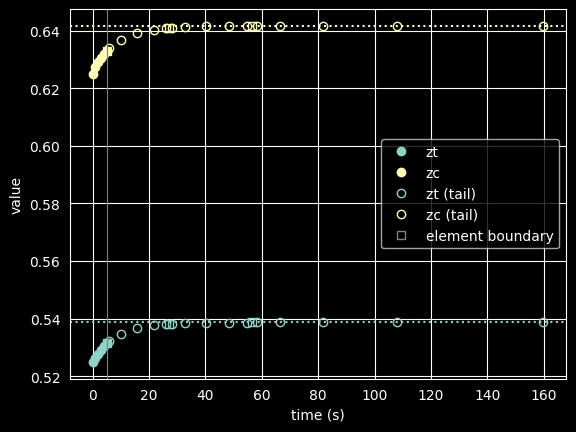

In [16]:
# Plot states: points only, as for model 3. Finite horizon filled,
# infinite tail open, mapped back to real time and clipped to the same
# window as the model 1 plot. Squares mark the segment's element
# boundaries (continuity extrapolations).

t4 = m4.i.get_finite_elements()
zc4 = [value(m4.zc[i]) for i in t4]
zt4 = [value(m4.zt[i]) for i in t4]

g4 = value(m4.gamma)
fe4 = set(m4.tau.get_finite_elements())
tail4 = [(tN4 + math.atanh(s)/g4, value(m4.zc_s[s]), value(m4.zt_s[s]), s in fe4)
         for s in sorted(m4.tau) if s < 1]
t_tail4 = [p[0] for p in tail4 if not p[3]]
zc_tail4 = [p[1] for p in tail4 if not p[3]]
zt_tail4 = [p[2] for p in tail4 if not p[3]]
t_fe4 = [p[0] for p in tail4 if p[3]]
zc_fe4 = [p[1] for p in tail4 if p[3]]
zt_fe4 = [p[2] for p in tail4 if p[3]]

line_zt, = plt.plot(t4, zt4, 'o', label='zt')
line_zc, = plt.plot(t4, zc4, 'o', label='zc')
plt.plot(t_tail4, zt_tail4, 'o', mfc='none', color=line_zt.get_color(), label='zt (tail)')
plt.plot(t_tail4, zc_tail4, 'o', mfc='none', color=line_zc.get_color(), label='zc (tail)')
plt.plot(t_fe4, zt_fe4, 's', mfc='none', color=line_zt.get_color())
plt.plot(t_fe4, zc_fe4, 's', mfc='none', color=line_zc.get_color())

plt.axhline(m4.xss[1], color=line_zc.get_color(), linestyle=':')
plt.axhline(m4.xss[2], color=line_zt.get_color(), linestyle=':')
plt.axvline(tN4, color='grey', linewidth=0.8)

plt.xlabel('time (s)')
plt.ylabel('value')
handles, labels = plt.gca().get_legend_handles_labels()
handles.append(Line2D([], [], marker='s', mfc='none', color='grey', linestyle=''))
labels.append('element boundary')
plt.legend(handles, labels)
plt.show()

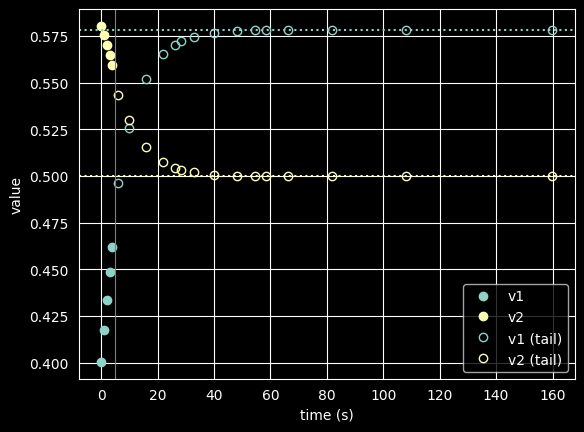

In [17]:
# Plot controls: points only. The profile's free values sit at the element
# collocation points; plot those through the tail (open markers).

v_tail4 = [(tN4 + math.atanh(s)/g4, value(m4.v1_s[s]), value(m4.v2_s[s]))
           for s in sorted(m4.v1_s.index_set()) if s < 1]
t_vt4 = [p[0] for p in v_tail4]
v1_t4 = [p[1] for p in v_tail4]
v2_t4 = [p[2] for p in v_tail4]

v1_4 = [value(m4.v1[i]) for i in t4[:-1]]
v2_4 = [value(m4.v2[i]) for i in t4[:-1]]

plt.figure()
line_v1, = plt.plot(t4[:-1], v1_4, 'o', label='v1')
line_v2, = plt.plot(t4[:-1], v2_4, 'o', label='v2')
plt.plot(t_vt4, v1_t4, 'o', mfc='none', color=line_v1.get_color(), label='v1 (tail)')
plt.plot(t_vt4, v2_t4, 'o', mfc='none', color=line_v2.get_color(), label='v2 (tail)')

plt.axhline(m4.uss[1], color=line_v1.get_color(), linestyle=':')
plt.axhline(m4.uss[2], color=line_v2.get_color(), linestyle=':')
plt.axvline(tN4, color='grey', linewidth=0.8)

plt.xlabel('time (s)')
plt.ylabel('value')
plt.legend()
plt.show()